<a href="https://colab.research.google.com/github/Raju-24-25/MNIST-Handwritten-Digit-Classification-using-TensorFlow-Keras/blob/main/MNIST_Handwritten_Digits_Recognition_Using_TensorFlow_and_Keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importing `Libraries`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import math
import datetime

import tensorflow as tf

### Load The `MNIST Handwritten Digits` Data

### The *training* dataset consists of 60000 - 28x28 px images of hand-written digits from 0 to 9.

### The *test* dataset consists of 10000 - 28x28 px images.

In [2]:
mnist_dataset = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist_dataset.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
print("Shape of the training data:", x_train.shape)
print("Shape of the testing data:", x_test.shape)

Shape of the training data: (60000, 28, 28)
Shape of the testing data: (10000, 28, 28)


In [5]:
print("Shape of training labels:", y_train.shape)
print("Shape of testing labels:", y_test.shape)

Shape of training labels: (60000,)
Shape of testing labels: (10000,)


### `Plotting` some of the `handwritten digits` image from the `training dataset`

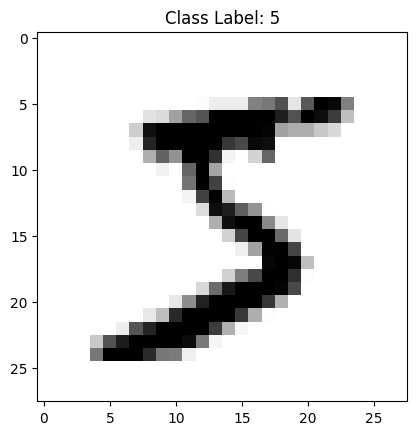

In [9]:
plt.figsize = (5,5)
plt.imshow(x_train[0], cmap = plt.cm.binary) #first image from the training dataset
plt.title(f"Class Label: {y_train[0]}", fontsize=12)
plt.show()

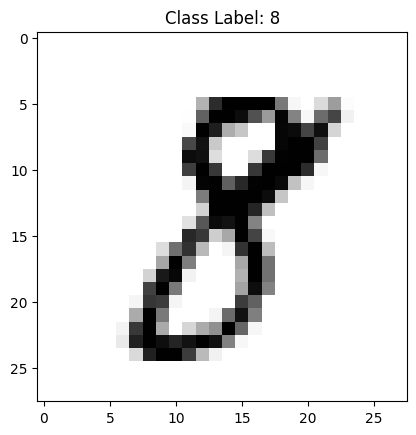

In [10]:
plt.figsize = (5,5)
plt.imshow(x_train[85], cmap = plt.cm.binary)
plt.title(f"Class Label: {y_train[85]}", fontsize=12)
plt.show()

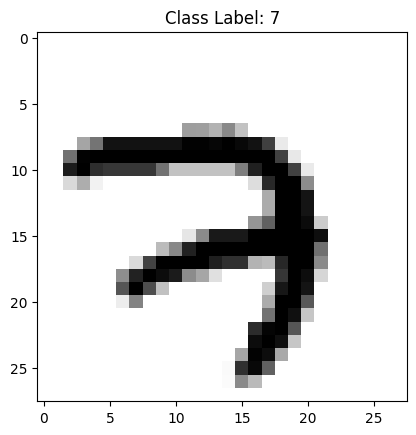

In [11]:
plt.figsize = (5,5)
plt.imshow(x_train[5000], cmap = plt.cm.binary)
plt.title(f"Class Label: {y_train[5000]}", fontsize=12)
plt.show()

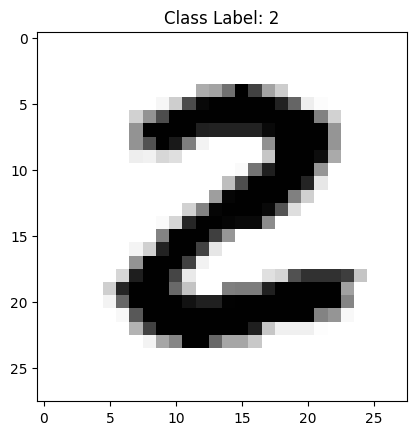

In [12]:
plt.figsize = (5,5)
plt.imshow(x_train[25], cmap = plt.cm.binary)
plt.title(f"Class Label: {y_train[25]}", fontsize=12)
plt.show()

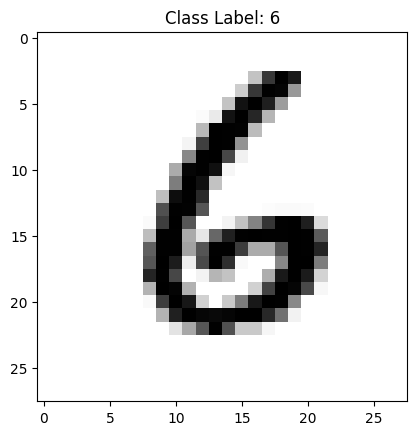

In [17]:
plt.figsize = (5,5)
plt.imshow(x_train[6000], cmap = plt.cm.binary)
plt.title(f"Class Label: {y_train[6000]}", fontsize=12)
plt.show()

### `Plot a few handwritten digits from the training dataset`

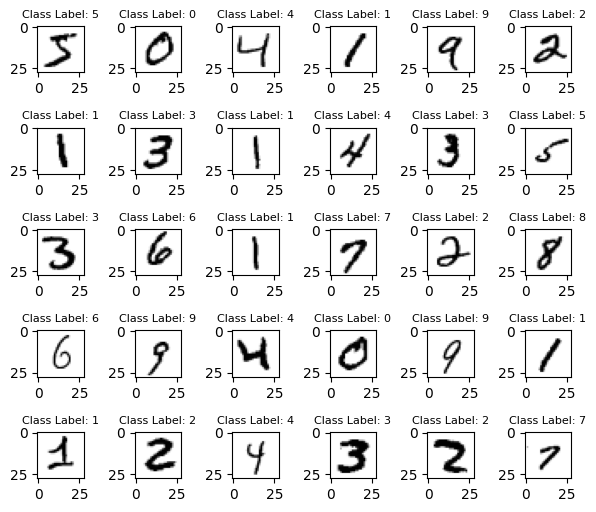

In [18]:
n = 30 # Select how many digits you want to plot
num_cells = math.ceil(math.sqrt(n))
plt.figure(figsize=(6, 6))

for i in range (n):

  plt.subplot(num_cells, num_cells, i+1)
  plt.title(f"Class Label: {y_train[i]}", fontsize=8)
  plt.imshow(x_train[i], cmap = plt.cm.binary)

plt.tight_layout()
plt.show()

### Let's plot a few images from the `testing dataset` as well

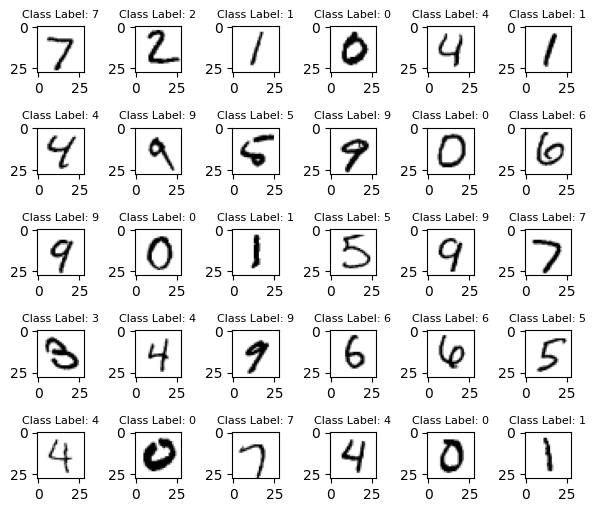

In [19]:
n = 30 # Select how many digits you want to plot
num_cells = math.ceil(math.sqrt(n))
plt.figure(figsize=(6, 6))

for i in range (n):

  plt.subplot(num_cells, num_cells, i+1)
  plt.title(f"Class Label: {y_test[i]}", fontsize=8)
  plt.imshow(x_test[i], cmap = plt.cm.binary)

plt.tight_layout()
plt.show()

## Let's Build the `MNIST Model`

In [21]:
model = tf.keras.models.Sequential()

In [22]:
model

<Sequential name=sequential_1, built=False>

#### Scale the `X_train` and `X_test` from [0-255] to [0-1]

In [23]:
x_train_normalized = x_train/255
x_test_normalized = x_test/255

In [26]:
x_train.min(), x_train.max()

(np.uint8(0), np.uint8(255))

In [27]:
x_train_normalized.min(), x_train_normalized.max()

(np.float64(0.0), np.float64(1.0))

In [28]:
# Input Layer
model.add(tf.keras.layers.Flatten(input_shape = x_train_normalized.shape[1:]))

# First Hidden Layer having size (no. of neurons = 128)
model.add(tf.keras.layers.Dense(
    units = 128,
    activation = tf.keras.activations.relu))

# Second Hidden Layer having size 128
model.add(tf.keras.layers.Dense(
    units = 128,
    activation = tf.keras.activations.relu))

# Output Layer
model.add(tf.keras.layers.Dense(
    units = 10,
    activation = tf.keras.activations.softmax

))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [29]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,282 (462.04 KB)

 Trainable params: 118,282 (462.04 KB)

 Non-trainable params: 0 (0.00 B)

### `Compile The Model`

In [30]:
adam_optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)

In [31]:
model.compile(
    optimizer = adam_optimizer,
    loss = tf.keras.losses.sparse_categorical_crossentropy,
    metrics = ['accuracy']
)

### `Train And Validate The Model`

In [32]:
training_history = model.fit(x_train_normalized, y_train, epochs = 30, validation_data = (x_test_normalized, y_test))

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9194 - loss: 0.2787 - val_accuracy: 0.9555 - val_loss: 0.1582
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9478 - loss: 0.1953 - val_accuracy: 0.9547 - val_loss: 0.1810
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9579 - loss: 0.1642 - val_accuracy: 0.9573 - val_loss: 0.1954
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9631 - loss: 0.1407 - val_accuracy: 0.9612 - val_loss: 0.1621
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9659 - loss: 0.1337 - val_accuracy: 0.9656 - val_loss: 0.1361
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9689 - loss: 0.1241 - val_accuracy: 0.9657 - val_loss: 0.1532
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9702 - loss: 0.1210 - val_accuracy: 0.9640 - val_loss: 0.1820
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9743 - loss: 0.1083

###
Plot `loss (both training & validation)` vs `epoch` and `accuracy (both training & validation)` vs `epoch`

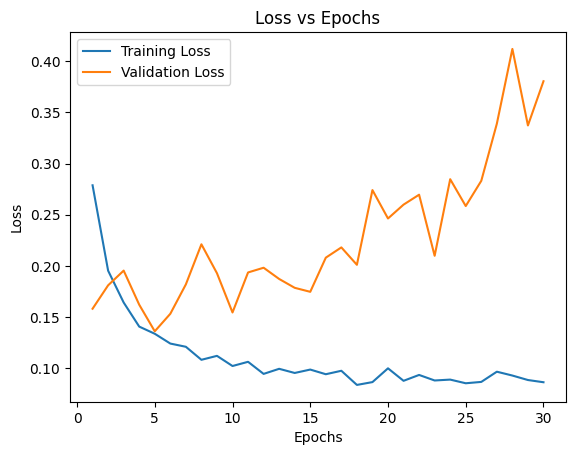

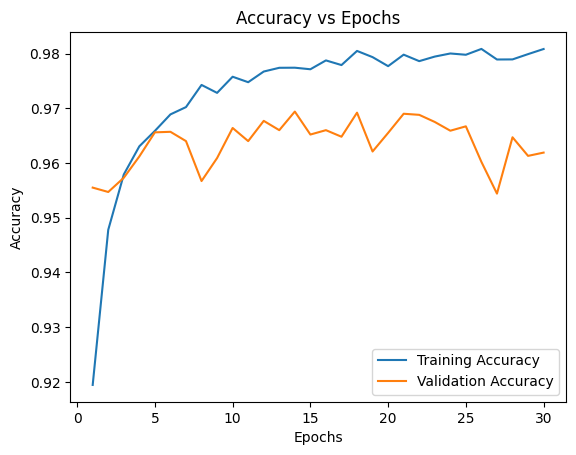

In [33]:
# Extract metrics
train_loss = training_history.history['loss']
val_loss = training_history.history['val_loss']
train_acc = training_history.history['accuracy']
val_acc = training_history.history['val_accuracy']

epochs = range(1, len(train_loss) + 1)

# Plot Loss
plt.figure()
plt.plot(epochs, train_loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.title('Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot Accuracy
plt.figure()
plt.plot(epochs, train_acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.title('Accuracy vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# `Iterate the same model with different configurations`

### `Step 1` : `Create a Configurable Model Function`

In [34]:
def build_and_train_model(learning_rate=0.001, epochs=10, hidden_layers=[128, 128]):

    model = tf.keras.models.Sequential()

    # Input layer
    model.add(tf.keras.layers.Flatten(input_shape=(28, 28)))

    # Hidden layers
    for neurons in hidden_layers:
        model.add(tf.keras.layers.Dense(units=neurons, activation='relu'))

    # Output layer
    model.add(tf.keras.layers.Dense(10, activation='softmax'))

    # Compile
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Train
    history = model.fit(
        x_train_normalized,
        y_train,
        validation_data=(x_test_normalized, y_test),
        epochs=epochs,
        verbose=0
    )

    return history

### `Step 2` : `Run Multiple Experiments`

In [35]:
configs = [
    {"lr": 0.01, "epochs": 10, "layers": [128, 128]},
    {"lr": 0.001, "epochs": 20, "layers": [128]},
    {"lr": 0.0005, "epochs": 30, "layers": [256, 128]},
    {"lr": 0.001, "epochs": 15, "layers": [64, 64, 32]},
]

results = []

for config in configs:
    print(f"Running config: {config}")

    history = build_and_train_model(
        learning_rate=config["lr"],
        epochs=config["epochs"],
        hidden_layers=config["layers"]
    )

    final_val_acc = history.history['val_accuracy'][-1]

    results.append({
        "config": config,
        "val_accuracy": final_val_acc
    })

Running config: {'lr': 0.01, 'epochs': 10, 'layers': [128, 128]}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Running config: {'lr': 0.001, 'epochs': 20, 'layers': [128]}
Running config: {'lr': 0.0005, 'epochs': 30, 'layers': [256, 128]}
Running config: {'lr': 0.001, 'epochs': 15, 'layers': [64, 64, 32]}


### `Step 3` : `Compare Results`

In [36]:
for res in results:
    print(f"Config: {res['config']} → Val Accuracy: {res['val_accuracy']:.4f}")

Config: {'lr': 0.01, 'epochs': 10, 'layers': [128, 128]} → Val Accuracy: 0.9582
Config: {'lr': 0.001, 'epochs': 20, 'layers': [128]} → Val Accuracy: 0.9800
Config: {'lr': 0.0005, 'epochs': 30, 'layers': [256, 128]} → Val Accuracy: 0.9822
Config: {'lr': 0.001, 'epochs': 15, 'layers': [64, 64, 32]} → Val Accuracy: 0.9742


In [37]:
test_loss, test_acc = model.evaluate(x_test_normalized, y_test)
print(f"Final Test Accuracy: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9619 - loss: 0.3804
Final Test Accuracy: 0.9619
